# YOLOv8n Fine-Tuning on LISA Traffic Signs

This notebook walks through every step of fine-tuning a YOLOv8n model on the LISA traffic-sign dataset.

**Steps**
1. Install dependencies
2. Set configuration
3. Prepare the LISA dataset (CSV → YOLO format)
4. Inspect the dataset
5. Load the base model
6. Train
7. Review metrics
8. Save the best model to `trained_models/`
9. Run a quick validation inference

## Step 0 — Google Colab Setup
Run this cell **only on Colab**. Skip it if running locally.

In [1]:
import sys, os

IN_COLAB = 'google.colab' in sys.modules or 'COLAB_GPU' in os.environ

if IN_COLAB:
    # ── Mount Google Drive ────────────────────────────────────────────────────
    from google.colab import drive
    drive.mount('/content/drive')

    # ── Install deps ──────────────────────────────────────────────────────────
    os.system('pip install ultralytics opencv-python-headless -q')

    # ── GPU check ─────────────────────────────────────────────────────────────
    import torch
    gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'
    vram_gb  = torch.cuda.get_device_properties(0).total_memory / 1e9 if torch.cuda.is_available() else 0
    print(f'GPU : {gpu_name}  |  VRAM: {vram_gb:.1f} GB')

    if not torch.cuda.is_available():
        raise RuntimeError('No GPU detected. Runtime → Change runtime type → A100 or V100 → Save & Reconnect')

    # ── Batch size based on VRAM ──────────────────────────────────────────────
    # A100 = ~40GB, V100 = ~16GB, T4 = ~15GB
    if vram_gb >= 35:       # A100
        _batch, _workers = 64, 8
    elif vram_gb >= 14:     # V100 / T4
        _batch, _workers = 32, 4
    else:
        _batch, _workers = 16, 2

    # ── Path overrides ────────────────────────────────────────────────────────
    DRIVE_PROJECT = '/content/drive/MyDrive/Capstone project/AAI-590-Capstone-group2-1'

    import pathlib
    REPO_ROOT  = pathlib.Path(DRIVE_PROJECT)
    LISA_ROOT  = REPO_ROOT / 'training_data' / 'Lisa'
    YOLO_DATA  = pathlib.Path('/content/lisa_yolo')   # local VM — faster I/O
    BASE_MODEL = REPO_ROOT / 'models' / 'yolov8n.pt'
    OUT_DIR    = REPO_ROOT / 'trained_models'

    # ── Training params ───────────────────────────────────────────────────────
    EPOCHS   = 100
    IMG_SIZE = 640
    BATCH    = _batch
    WORKERS  = _workers
    LR0      = 0.01
    PATIENCE = 20
    AUGMENT  = True
    FREEZE   = 0
    DEVICE   = '0'

    RUN_PROJECT = '/content/runs/train'
    RUN_NAME    = 'lisa_yolov8n'
    VAL_SPLIT   = 0.15
    SEED        = 42

    sys.path.insert(0, str(REPO_ROOT / 'training'))

    print(f'REPO_ROOT  : {REPO_ROOT}  exists={REPO_ROOT.exists()}')
    print(f'LISA_ROOT  : {LISA_ROOT}  exists={LISA_ROOT.exists()}')
    print(f'BASE_MODEL : {BASE_MODEL}  exists={BASE_MODEL.exists()}')
    print(f'DEVICE     : {DEVICE}  |  BATCH={BATCH}  WORKERS={WORKERS}  EPOCHS={EPOCHS}')
else:
    print('Not on Colab — skipping. Proceed to Step 2.')


Mounted at /content/drive
GPU : NVIDIA A100-SXM4-40GB  |  VRAM: 42.4 GB
REPO_ROOT  : /content/drive/MyDrive/Capstone project/AAI-590-Capstone-group2-1  exists=True
LISA_ROOT  : /content/drive/MyDrive/Capstone project/AAI-590-Capstone-group2-1/training_data/Lisa  exists=True
BASE_MODEL : /content/drive/MyDrive/Capstone project/AAI-590-Capstone-group2-1/models/yolov8n.pt  exists=True
DEVICE     : 0  |  BATCH=64  WORKERS=8  EPOCHS=100


In [2]:
# ── GPU Verification (Colab Pro) ─────────────────────────────────────────────
import torch

print('torch version  :', torch.__version__)
print('CUDA available :', torch.cuda.is_available())

if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f'GPU name       : {props.name}')
    print(f'VRAM           : {props.total_memory / 1e9:.1f} GB')
    print(f'CUDA version   : {torch.version.cuda}')
    # Quick tensor test
    x = torch.zeros(1).cuda()
    print(f'Tensor device  : {x.device}')
    print('\nGPU is ready.')
else:
    print('\nNo GPU — go to: Runtime → Change runtime type → A100 → Save')


torch version  : 2.10.0+cu128
CUDA available : True
GPU name       : NVIDIA A100-SXM4-40GB
VRAM           : 42.4 GB
CUDA version   : 12.8
Tensor device  : cuda:0

GPU is ready.


## Step 1 — Install Dependencies

In [3]:
# Run once; restart kernel if packages were freshly installed
%pip install ultralytics opencv-python-headless --quiet

## Step 2 — Configuration

Edit the variables below before running the rest of the notebook.

In [4]:
import sys, os
import torch
from pathlib import Path

# On Colab, Step 0 already set all variables — skip this cell
IN_COLAB = 'google.colab' in sys.modules or 'COLAB_GPU' in os.environ
if IN_COLAB:
    print('Colab detected — Step 0 config is active. Skipping Step 2.')
else:
    # ── Paths ────────────────────────────────────────────────────────────
    REPO_ROOT  = Path('../').resolve()
    LISA_ROOT  = REPO_ROOT / 'training_data' / 'Lisa'
    YOLO_DATA  = REPO_ROOT / 'training' / 'lisa_yolo'
    BASE_MODEL = REPO_ROOT / 'models' / 'yolov8n.pt'
    OUT_DIR    = REPO_ROOT / 'trained_models'

    # ── Device — validate before trusting ────────────────────────────────
    def _detect_device() -> str:
        if torch.cuda.is_available():
            try:
                torch.zeros(1).cuda()
                return '0'
            except Exception:
                pass
        if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
            try:
                torch.zeros(1).to('mps')
                return 'mps'
            except Exception:
                pass
        return 'cpu'

    DEVICE = _detect_device()

    # ── Training hyper-parameters ─────────────────────────────────────────
    EPOCHS   = 50
    IMG_SIZE = 640
    BATCH    = 8  if DEVICE == 'cpu' else 16
    WORKERS  = 0  if DEVICE == 'cpu' else 4
    LR0      = 0.01
    PATIENCE = 15
    AUGMENT  = True
    FREEZE   = 0

    RUN_PROJECT = str(REPO_ROOT / 'runs' / 'train')
    RUN_NAME    = 'lisa_yolov8n'
    VAL_SPLIT   = 0.15
    SEED        = 42

    sys.path.insert(0, str(REPO_ROOT / 'training'))

    print('REPO_ROOT :', REPO_ROOT)
    print('LISA_ROOT :', LISA_ROOT, '→ exists:', LISA_ROOT.exists())
    print('BASE_MODEL:', BASE_MODEL, '→ exists:', BASE_MODEL.exists())
    print(f'Device    : {DEVICE}')


Colab detected — Step 0 config is active. Skipping Step 2.


## Step 3 — Prepare the LISA Dataset

Reads all `frameAnnotationsBOX.csv` files, converts bounding boxes to normalised
YOLO format, splits into train / val, and writes `dataset.yaml`.

> **Skip this cell** if you have already run it once and `lisa_yolo/` exists.

In [12]:
import sys
from pathlib import Path
import shutil

# Ensure prepare_lisa.py is importable (critical on Colab)
training_dir = REPO_ROOT / 'training'
if str(training_dir) not in sys.path:
    sys.path.insert(0, str(training_dir))

print("Importing prepare_lisa module...")
from prepare_lisa import prepare
print("prepare_lisa module imported successfully.")

# --- Copy LISA dataset to local Colab VM for faster I/O ---
LOCAL_LISA_ROOT = Path('/content/lisa_raw')

# Configuration for copying a subset
COPY_LISA_SUBSET = True # Set to False to copy the entire dataset
LISA_NUM_TOP_LEVEL_IMG_FOLDERS_TO_COPY = 1 # Number of top-level image folders (e.g., dayTrain, daySequence1) to copy

# If LOCAL_LISA_ROOT already exists, remove it to ensure a fresh copy
if LOCAL_LISA_ROOT.exists():
    print(f"Removing existing local LISA dataset at {LOCAL_LISA_ROOT}...")
    shutil.rmtree(LOCAL_LISA_ROOT)
    print("Removal complete. Preparing for fresh copy.")

# Now proceed with copying
LOCAL_LISA_ROOT.mkdir(parents=True, exist_ok=True) # Create the destination root

if COPY_LISA_SUBSET:
    # First, copy the Annotations folder
    annotations_src = LISA_ROOT / 'Annotations'
    if annotations_src.exists() and annotations_src.is_dir():
        annotations_dst = LOCAL_LISA_ROOT / 'Annotations'
        print(f"  Copying Annotations folder from {annotations_src} to {annotations_dst}...")
        shutil.copytree(annotations_src, annotations_dst)
        print("  Annotations copy complete.")
    else:
        print(f"  Warning: Annotations folder not found at {annotations_src}. Please ensure your LISA_ROOT is correctly configured.")

    # Then, copy a subset of the *top-level* image directories (e.g., dayTrain, daySequenceX)
    print(f"Copying a subset of top-level LISA image directories ({LISA_NUM_TOP_LEVEL_IMG_FOLDERS_TO_COPY} folders) from {LISA_ROOT} to local VM {LOCAL_LISA_ROOT}...")
    copied_count = 0
    for item in sorted(LISA_ROOT.iterdir()):
        # Check for top-level directories that contain images
        if item.is_dir() and (item.name.startswith('dayTrain') or item.name.startswith('daySequence') or item.name.startswith('nightTrain') or item.name.startswith('nightSequence')) and copied_count < LISA_NUM_TOP_LEVEL_IMG_FOLDERS_TO_COPY:
            dest_path = LOCAL_LISA_ROOT / item.name
            print(f"  Copying {item.name}...")
            shutil.copytree(item, dest_path)
            copied_count += 1
    print("Subset top-level image directories copy complete.")
    if copied_count == 0:
        print(f"Warning: No 'dayTrain', 'daySequenceX', 'nightTrain', or 'nightSequenceX' folders found in {LISA_ROOT} to copy. Listing contents of LISA_ROOT to debug:")
        import os
        for root, dirs, files in os.walk(LISA_ROOT):
            print(f"  Directory: {root}")
            for d in dirs:
                print(f"    Subdirectory: {d}")
            for f in files:
                print(f"    File: {f}")

else:
    print(f"Copying entire LISA dataset from {LISA_ROOT} to local VM {LOCAL_LISA_ROOT}...")
    shutil.copytree(LISA_ROOT, LOCAL_LISA_ROOT)
    print("Entire dataset copy complete.")

print("Starting dataset preparation...")
yaml_path = prepare(
    lisa_root=str(LOCAL_LISA_ROOT), # Use the local path here
    out_root=str(YOLO_DATA),
    val_split=VAL_SPLIT,
    seed=SEED,
    max_images=500, # Added to process only 500 images
)
print("Dataset preparation complete.")
print('\ndataset.yaml:', yaml_path)

Importing prepare_lisa module...
prepare_lisa module imported successfully.
Removing existing local LISA dataset at /content/lisa_raw...
Removal complete. Preparing for fresh copy.
  Copying Annotations folder from /content/drive/MyDrive/Capstone project/AAI-590-Capstone-group2-1/training_data/Lisa/Annotations to /content/lisa_raw/Annotations...
  Annotations copy complete.
Copying a subset of top-level LISA image directories (1 folders) from /content/drive/MyDrive/Capstone project/AAI-590-Capstone-group2-1/training_data/Lisa to local VM /content/lisa_raw...
  Copying daySequence1...
Subset top-level image directories copy complete.
Starting dataset preparation...


Dataset preparation complete.

dataset.yaml: /content/lisa_yolo/dataset.yaml


## Step 4 — Inspect the Dataset

In [13]:
import sys
from pathlib import Path
from collections import Counter

# Ensure training modules are importable (Colab + local)
training_dir = REPO_ROOT / 'training'
if str(training_dir) not in sys.path:
    sys.path.insert(0, str(training_dir))

from lisa_classes import CLASS_NAMES

# ── File counts ──────────────────────────────────────────────────────────
train_imgs = list((YOLO_DATA / 'images' / 'train').glob('*.jpg'))
val_imgs   = list((YOLO_DATA / 'images' / 'val').glob('*.jpg'))
print(f'Train images : {len(train_imgs)}')
print(f'Val   images : {len(val_imgs)}')

# ── Class distribution ───────────────────────────────────────────────────
counter: Counter = Counter()
for split in ('train', 'val'):
    for lbl_file in (YOLO_DATA / 'labels' / split).glob('*.txt'):
        for line in lbl_file.read_text().splitlines():
            if line.strip():
                counter[int(line.split()[0])] += 1

print('\nAnnotation counts per class:')
for idx, name in enumerate(CLASS_NAMES):
    print(f'  {idx:2d}  {name:<20s} {counter.get(idx, 0):>6d}')


Train images : 425
Val   images : 75

Annotation counts per class:
   0  go                      714
   1  goForward                 0
   2  goLeft                    0
   3  stop                    418
   4  stopLeft                  1
   5  warning                  45
   6  warningLeft               5


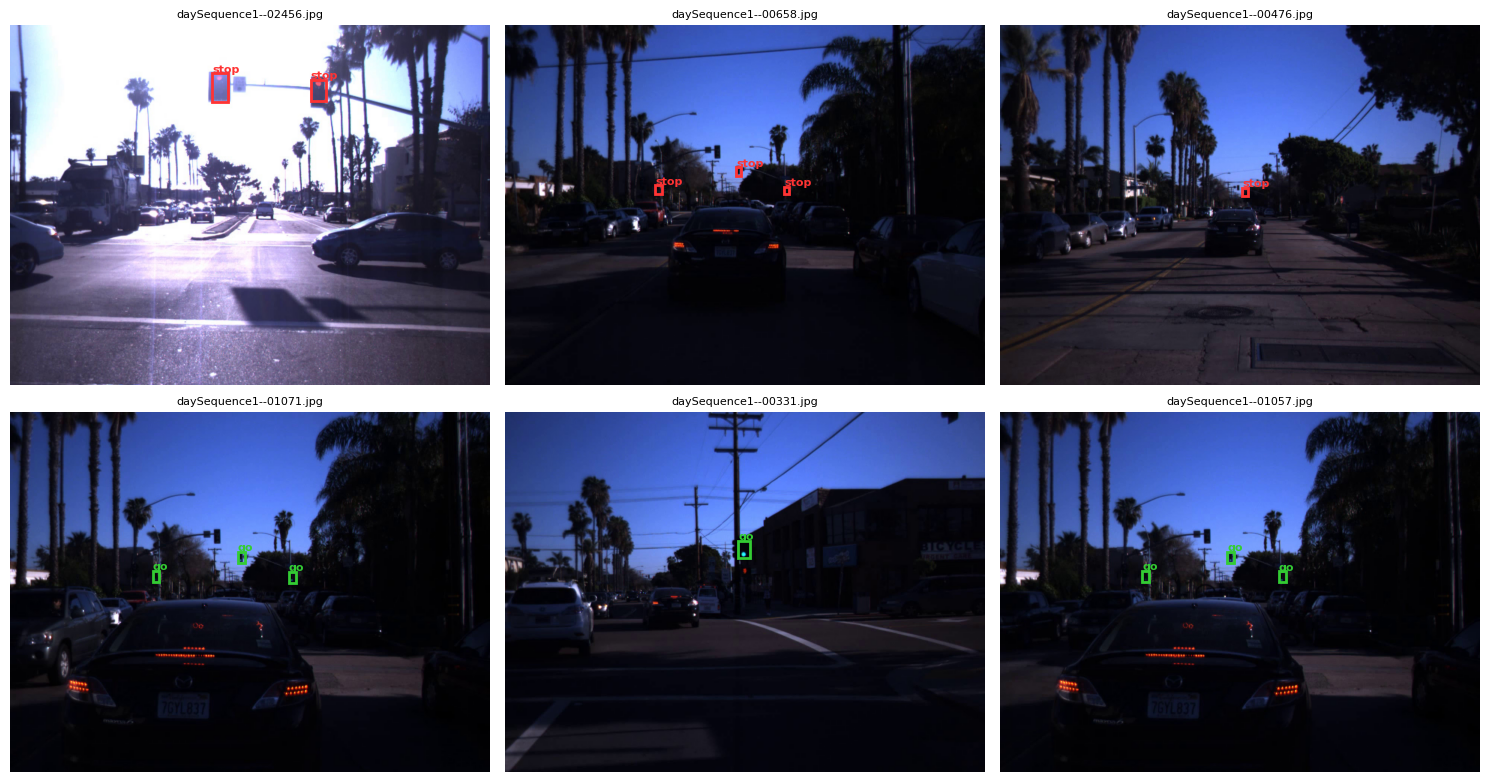

In [14]:
# ── Visualise a random training sample ───────────────────────────────────────
import random
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches

COLORS = [
    (0.2, 0.8, 0.2),  # go         – green
    (0.0, 0.6, 1.0),  # goForward  – blue
    (0.0, 1.0, 1.0),  # goLeft     – cyan
    (1.0, 0.2, 0.2),  # stop       – red
    (1.0, 0.5, 0.0),  # stopLeft   – orange
    (1.0, 1.0, 0.0),  # warning    – yellow
    (0.8, 0.0, 0.8),  # warningLeft– purple
]

random.seed(0)
sample_imgs = random.sample(train_imgs, min(6, len(train_imgs)))

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, img_path in zip(axes.flat, sample_imgs):
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    ax.imshow(img)

    lbl_path = YOLO_DATA / "labels" / "train" / (img_path.stem + ".txt")
    if lbl_path.exists():
        for line in lbl_path.read_text().splitlines():
            parts = line.split()
            if len(parts) < 5:
                continue
            cls_idx = int(parts[0])
            cx, cy, bw, bh = map(float, parts[1:])
            x1 = (cx - bw / 2) * w
            y1 = (cy - bh / 2) * h
            color = COLORS[cls_idx % len(COLORS)]
            rect = patches.Rectangle(
                (x1, y1), bw * w, bh * h,
                linewidth=2, edgecolor=color, facecolor="none"
            )
            ax.add_patch(rect)
            ax.text(
                x1, y1 - 4, CLASS_NAMES[cls_idx],
                color=color, fontsize=8, fontweight="bold"
            )

    ax.set_title(img_path.name, fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Step 5 — Load the Base Model

In [15]:
from ultralytics import YOLO

model = YOLO(str(BASE_MODEL))
print("Model loaded:", BASE_MODEL.name)
print("Parameters  :", sum(p.numel() for p in model.model.parameters()), "total")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Model loaded: yolov8n.pt
Parameters  : 3157200 total


## Step 6 — Train

Progress bars and per-epoch metrics will stream directly into this cell's output.
Training writes checkpoints to `runs/train/lisa_yolov8n/weights/`.

In [16]:
from ultralytics import YOLO

# yaml_path may not be set if Step 3 was skipped — resolve from config
yaml_path = YOLO_DATA / 'dataset.yaml'
if not yaml_path.exists():
    raise FileNotFoundError(
        f'Dataset YAML not found: {yaml_path}\nRun Step 3 first.'
    )

model = YOLO(str(BASE_MODEL))

train_kwargs = dict(
    data       = str(yaml_path.resolve()),
    epochs     = EPOCHS,
    imgsz      = IMG_SIZE,
    batch      = BATCH,
    workers    = WORKERS,
    device     = DEVICE,
    lr0        = LR0,
    patience   = PATIENCE,
    project    = RUN_PROJECT,
    name       = RUN_NAME,
    exist_ok   = True,
    mosaic     = 1.0 if AUGMENT else 0.0,
    copy_paste = 0.0,   # disabled — causes shape mismatch on LISA
    freeze     = FREEZE if FREEZE > 0 else None,
    verbose    = True,
    save       = True,
    save_period= -1,
)

print('Training config:')
for k, v in train_kwargs.items():
    print(f'  {k:<12}: {v}')

results = model.train(**train_kwargs)
print('\nTraining complete.')


Training config:
  data        : /content/lisa_yolo/dataset.yaml
  epochs      : 100
  imgsz       : 640
  batch       : 64
  workers     : 8
  device      : 0
  lr0         : 0.01
  patience    : 20
  project     : /content/runs/train
  name        : lisa_yolov8n
  exist_ok    : True
  mosaic      : 1.0
  copy_paste  : 0.0
  freeze      : None
  verbose     : True
  save        : True
  save_period : -1
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/lisa_yolo/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0

## Step 7 — Review Metrics

In [17]:
# ── Scalar summary ───────────────────────────────────────────────────────────
metrics = results.results_dict
print("Final validation metrics:")
for key in (
    "metrics/mAP50(B)",
    "metrics/mAP50-95(B)",
    "metrics/precision(B)",
    "metrics/recall(B)",
):
    print(f"  {key:<30s}: {metrics.get(key, float('nan')):.4f}")

Final validation metrics:
  metrics/mAP50(B)              : 0.9725
  metrics/mAP50-95(B)           : 0.6455
  metrics/precision(B)          : 0.9487
  metrics/recall(B)             : 0.9273


/tmp/ipykernel_709/150780517.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


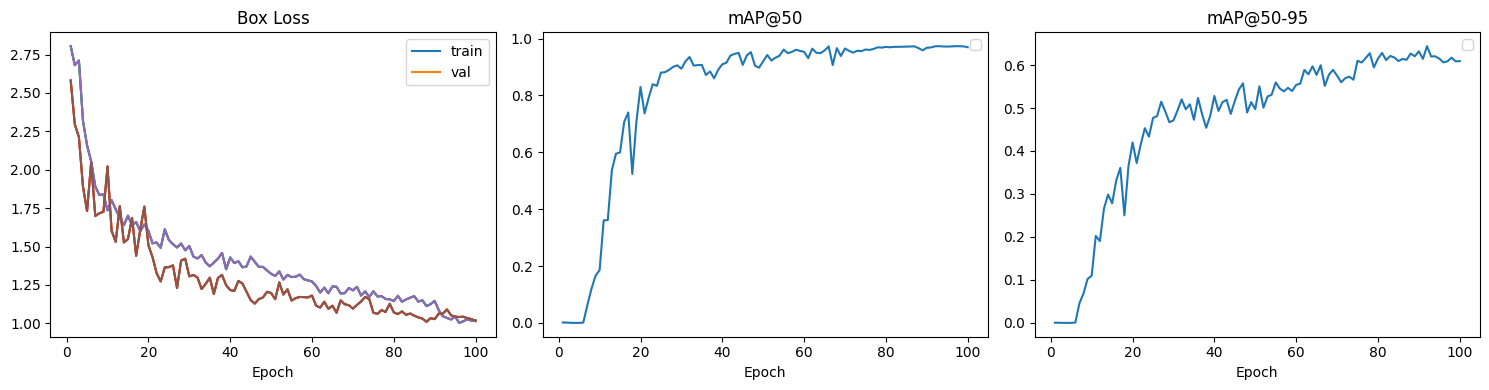

In [18]:
# ── Training curves (loss + mAP) ─────────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt

results_csv = Path(RUN_PROJECT) / RUN_NAME / "results.csv"

if results_csv.exists():
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Box loss
    for col, ax, title in [
        ("train/box_loss",        axes[0], "Box Loss"),
        ("metrics/mAP50(B)",      axes[1], "mAP@50"),
        ("metrics/mAP50-95(B)",   axes[2], "mAP@50-95"),
    ]:
        if col in df.columns:
            axes[0].plot(df["epoch"], df["train/box_loss"], label="train")
            if "val/box_loss" in df.columns:
                axes[0].plot(df["epoch"], df["val/box_loss"], label="val")
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.legend()

    if "metrics/mAP50(B)" in df.columns:
        axes[1].plot(df["epoch"], df["metrics/mAP50(B)"])
    if "metrics/mAP50-95(B)" in df.columns:
        axes[2].plot(df["epoch"], df["metrics/mAP50-95(B)"])

    plt.tight_layout()
    plt.show()
else:
    print("results.csv not found – check", RUN_PROJECT)

## Step 8 — Save Best Model to `trained_models/`

In [19]:
import shutil

run_dir = Path(RUN_PROJECT) / RUN_NAME
best_pt = run_dir / "weights" / "best.pt"
last_pt = run_dir / "weights" / "last.pt"

OUT_DIR.mkdir(parents=True, exist_ok=True)

dest_best = OUT_DIR / "yolov8n_lisa_best.pt"
shutil.copy2(best_pt, dest_best)
print("Best model  →", dest_best)

if last_pt.exists():
    dest_last = OUT_DIR / "yolov8n_lisa_last.pt"
    shutil.copy2(last_pt, dest_last)
    print("Last checkpoint →", dest_last)

Best model  → /content/drive/MyDrive/Capstone project/AAI-590-Capstone-group2-1/trained_models/yolov8n_lisa_best.pt
Last checkpoint → /content/drive/MyDrive/Capstone project/AAI-590-Capstone-group2-1/trained_models/yolov8n_lisa_last.pt


## Step 9 — Quick Validation Inference

Runs the saved model on a few val images so you can visually confirm it is detecting signs.

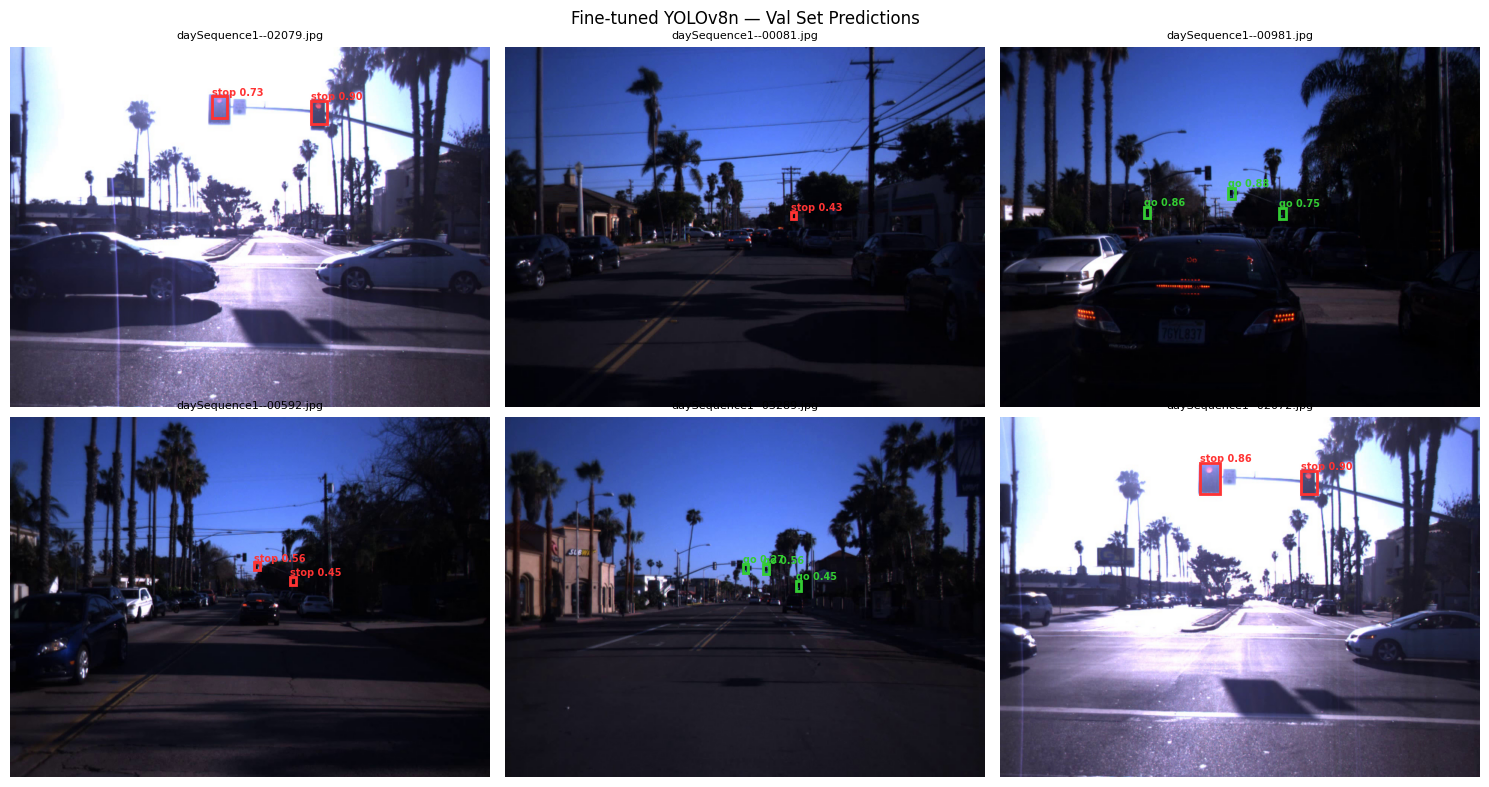

In [20]:
import random
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from ultralytics import YOLO

infer_model = YOLO(str(dest_best))

val_imgs_list = list((YOLO_DATA / "images" / "val").glob("*.jpg"))
random.seed(1)
sample = random.sample(val_imgs_list, min(6, len(val_imgs_list)))

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, img_path in zip(axes.flat, sample):
    img_bgr = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w = img_rgb.shape[:2]

    preds = infer_model.predict(img_bgr, conf=0.25, verbose=False)[0]

    ax.imshow(img_rgb)
    for box in preds.boxes:
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        cls_idx = int(box.cls[0])
        conf    = float(box.conf[0])
        color   = COLORS[cls_idx % len(COLORS)]
        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2, edgecolor=color, facecolor="none"
        )
        ax.add_patch(rect)
        label = f"{CLASS_NAMES[cls_idx]} {conf:.2f}"
        ax.text(x1, y1 - 4, label, color=color, fontsize=7, fontweight="bold")

    ax.set_title(img_path.name, fontsize=8)
    ax.axis("off")

plt.suptitle("Fine-tuned YOLOv8n — Val Set Predictions", fontsize=12)
plt.tight_layout()
plt.show()

## (Optional) Resume Training from Last Checkpoint

If training was interrupted, run the cell below to continue from where it stopped.

In [ ]:
last_ckpt = Path(RUN_PROJECT) / RUN_NAME / "weights" / "last.pt"

if last_ckpt.exists():
    resume_model = YOLO(str(last_ckpt))
    results = resume_model.train(resume=True)
    print("Resumed training complete.")
else:
    print("No last.pt found at", last_ckpt)